In [6]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg
from scipy.optimize import minimize
import copy
import os

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
dtype = torch.float32

print("Device:", device)
print("Dtype:", dtype)

Device: mps
Dtype: torch.float32


In [3]:
class MVDCNODEFunc(nn.Module):
    def __init__(self, state_dim=5, input_dim=1, disturbance_dim=1, hidden_dim=128):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(state_dim + input_dim + disturbance_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, state_dim),
        )

    def forward(self, z, u_norm, d_norm):
        """
        z shape      : [batch_size, 5]
        u_norm shape : [batch_size, 1]
        d_norm shape : [batch_size, 1]

        return dzdt shape: [batch_size, 5]
        """

        inp = torch.cat([z, u_norm, d_norm], dim=1)
        dzdt = self.net(inp)

        return dzdt

In [8]:
# ============================================================
# Load trained MVDC NODE checkpoint
# ============================================================

checkpoint_path = "/Users/hotrongtai/Downloads/Pre_learning/MVDC/mvdc_node_checkpoint.pt"

if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

# Compatible with different PyTorch versions
try:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False
    )
except TypeError:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

print("Loaded checkpoint keys:")
for k in checkpoint.keys():
    print(" -", k)

Loaded checkpoint keys:
 - model_state_dict
 - x_op
 - u_op
 - d_op
 - x_scale
 - u_scale
 - d_scale
 - params
 - dt
 - best_val_loss


In [10]:
# ============================================================
# Rebuild model and load weights
# ============================================================

# Infer hidden_dim from checkpoint if possible
state_dict = checkpoint["model_state_dict"]

first_layer_weight = state_dict["net.0.weight"]
hidden_dim = first_layer_weight.shape[0]

print("Inferred hidden_dim:", hidden_dim)

node_model = MVDCNODEFunc(
    state_dim=5,
    input_dim=1,
    disturbance_dim=1,
    hidden_dim=hidden_dim
).to(device)

node_model.load_state_dict(state_dict)
node_model = node_model.to(device=device, dtype=dtype)

node_model.eval()

print("NODE model loaded successfully.")

Inferred hidden_dim: 128
NODE model loaded successfully.


In [16]:
# ============================================================
# Restore operating point, normalization scales, and parameters
# ============================================================

x_op = checkpoint["x_op"].to(device=device, dtype=dtype)
u_op = checkpoint["u_op"].to(device=device, dtype=dtype)
d_op = checkpoint["d_op"].to(device=device, dtype=dtype)

x_scale = checkpoint["x_scale"].to(device=device, dtype=dtype)
u_scale = checkpoint["u_scale"].to(device=device, dtype=dtype)
d_scale = checkpoint["d_scale"].to(device=device, dtype=dtype)

params = checkpoint["params"]

dt_phys = checkpoint["dt"]

print("=" * 80)
print("Restored MVDC NODE setup")
print("=" * 80)

print("x_op:", x_op)
print("u_op:", u_op)
print("d_op:", d_op)

print("\nx_scale:", x_scale)
print("u_scale:", u_scale)
print("d_scale:", d_scale)

print("\nparams:")
for k, v in params.items():
    print(f"{k:<10}: {v}")

print("\ndt_phys:", dt_phys)

print("=" * 80)

Restored MVDC NODE setup
x_op: tensor([6000.0000,  909.0909,  454.5454,  202.0202,  101.0101], device='mps:0')
u_op: tensor([0.], device='mps:0')
d_op: tensor([10000000.], device='mps:0')

x_scale: tensor([16.1471, 40.4549, 34.5601, 32.0333, 23.6247], device='mps:0')
u_scale: tensor([510.], device='mps:0')
d_scale: tensor([487667.3438], device='mps:0')

params:
Rsga      : 0.05
Rsgb      : 0.1
Rbata     : 0.225
Rbatb     : 0.45
Ceq       : 0.01
Lsg       : 0.001
Lbat      : 0.0008
Vref      : 6045.454545454545

dt_phys: 0.0001


In [17]:
# ============================================================
# RK4 step for normalized NODE
# ============================================================

def rk4_step_node_norm(node_func, z, u_norm, d_norm, dt):
    """
    z shape      : [batch_size, 5]
    u_norm shape : [batch_size, 1]
    d_norm shape : [batch_size, 1]
    """

    k1 = node_func(z, u_norm, d_norm)
    k2 = node_func(z + 0.5 * dt * k1, u_norm, d_norm)
    k3 = node_func(z + 0.5 * dt * k2, u_norm, d_norm)
    k4 = node_func(z + dt * k3, u_norm, d_norm)

    z_next = z + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    return z_next

In [20]:
# ============================================================
# Sanity check loaded NODE
# ============================================================

with torch.no_grad():
    z_op = torch.zeros(1, 5, device=device, dtype=dtype)
    u_op_norm = torch.zeros(1, 1, device=device, dtype=dtype)
    d_op_norm = torch.zeros(1, 1, device=device, dtype=dtype)

    dzdt_op = node_model(z_op, u_op_norm, d_op_norm)

print("dzdt at normalized operating point:")
print(dzdt_op.detach().cpu().numpy())

print("norm dzdt:", torch.norm(dzdt_op).item())

dzdt at normalized operating point:
[[-0.00181472 -0.00405337 -0.00341178 -0.00454354 -0.00420981]]
norm dzdt: 0.00835041981190443


In [24]:
# ============================================================
# Export trained PyTorch NODE to NumPy weights
# ============================================================

def export_node_weights_to_numpy(node_model):
    """
    Export Sequential MLP weights to numpy.
    Assumes architecture:
        Linear -> Tanh -> Linear -> Tanh -> Linear
    """

    state_dict = node_model.state_dict()

    weights = {
        "W1": state_dict["net.0.weight"].detach().cpu().numpy(),
        "b1": state_dict["net.0.bias"].detach().cpu().numpy(),

        "W2": state_dict["net.2.weight"].detach().cpu().numpy(),
        "b2": state_dict["net.2.bias"].detach().cpu().numpy(),

        "W3": state_dict["net.4.weight"].detach().cpu().numpy(),
        "b3": state_dict["net.4.bias"].detach().cpu().numpy(),
    }

    return weights


node_weights_np = export_node_weights_to_numpy(node_model)

# Convert restored tensors/scalars to NumPy
x_op_np = x_op.detach().cpu().numpy()
u_op_np = u_op.detach().cpu().numpy()
d_op_np = d_op.detach().cpu().numpy()

x_scale_np = x_scale.detach().cpu().numpy()
u_scale_np = u_scale.detach().cpu().numpy()
d_scale_np = d_scale.detach().cpu().numpy()

dt_phys_np = float(dt_phys)
time_scale_np = float(1e-3)
dt_model_np = float(1e-4/1e-3)

print("Exported NODE weights to NumPy.")
print("x_op_np:", x_op_np)
print("u_op_np:", u_op_np)
print("d_op_np:", d_op_np)
print("dt_model_np:", dt_model_np)

Exported NODE weights to NumPy.
x_op_np: [6000.       909.0909   454.54544  202.0202   101.0101 ]
u_op_np: [0.]
d_op_np: [1.e+07]
dt_model_np: 0.1


In [25]:
# ============================================================
# NumPy NODE forward
# ============================================================

def node_forward_np(z, u_norm, d_norm, weights):
    """
    NumPy forward pass for trained MVDC NODE.

    z shape      : [batch, 5]
    u_norm shape : [batch, 1]
    d_norm shape : [batch, 1]

    return:
        dzdt shape: [batch, 5]
    """

    inp = np.concatenate([z, u_norm, d_norm], axis=1)

    h1 = np.tanh(inp @ weights["W1"].T + weights["b1"])
    h2 = np.tanh(h1 @ weights["W2"].T + weights["b2"])
    out = h2 @ weights["W3"].T + weights["b3"]

    return out

In [26]:
# ============================================================
# NumPy RK4 one-step NODE
# ============================================================

def rk4_step_node_np(z, u_norm, d_norm, dt_model, weights):
    """
    RK4 step in normalized coordinates using NumPy NODE.
    """

    k1 = node_forward_np(z, u_norm, d_norm, weights)
    k2 = node_forward_np(z + 0.5 * dt_model * k1, u_norm, d_norm, weights)
    k3 = node_forward_np(z + 0.5 * dt_model * k2, u_norm, d_norm, weights)
    k4 = node_forward_np(z + dt_model * k3, u_norm, d_norm, weights)

    z_next = z + (dt_model / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    return z_next


def node_one_step_np(z_flat, u_flat, d_flat, dt_model, weights):
    """
    One-step map with flat inputs.
    Used for finite-difference linearization.
    """

    z = z_flat.reshape(1, -1)
    u = u_flat.reshape(1, -1)
    d = d_flat.reshape(1, -1)

    z_next = rk4_step_node_np(
        z=z,
        u_norm=u,
        d_norm=d,
        dt_model=dt_model,
        weights=weights
    )

    return z_next.reshape(-1)

In [27]:
# ============================================================
# Compute MVDC reference equilibrium in NumPy
# ============================================================

def compute_mvdc_reference_equilibrium_np(Vo_ref, P_ref, params):
    Rsga = params["Rsga"]
    Rsgb = params["Rsgb"]
    Rbata = params["Rbata"]
    Rbatb = params["Rbatb"]
    Vref = params["Vref"]

    G_total = 1/Rsga + 1/Rsgb + 1/Rbata + 1/Rbatb

    Iload_ref = P_ref / Vo_ref
    DeltaV_ref = Iload_ref / G_total

    Isga_ref = DeltaV_ref / Rsga
    Isgb_ref = DeltaV_ref / Rsgb
    Ibata_ref = DeltaV_ref / Rbata
    Ibatb_ref = DeltaV_ref / Rbatb

    u_ref = Vo_ref + DeltaV_ref - Vref

    x_ref_abs = np.array(
        [Vo_ref, Isga_ref, Isgb_ref, Ibata_ref, Ibatb_ref],
        dtype=np.float64
    )

    u_ref_abs = np.array([u_ref], dtype=np.float64)
    d_ref_abs = np.array([P_ref], dtype=np.float64)

    return x_ref_abs, u_ref_abs, d_ref_abs


Vo_ref = 6100.0
P_ref = 10e6

x_ref_abs_np, u_ref_abs_np, d_ref_abs_np = compute_mvdc_reference_equilibrium_np(
    Vo_ref=Vo_ref,
    P_ref=P_ref,
    params=params
)

z_ref_np = (x_ref_abs_np - x_op_np) / x_scale_np
u_ref_norm_np = (u_ref_abs_np - u_op_np) / u_scale_np
d_ref_norm_np = (d_ref_abs_np - d_op_np) / d_scale_np

print("x_ref_abs_np:", x_ref_abs_np)
print("u_ref_abs_np:", u_ref_abs_np)
print("d_ref_abs_np:", d_ref_abs_np)

print("\nz_ref_np:", z_ref_np)
print("u_ref_norm_np:", u_ref_norm_np)
print("d_ref_norm_np:", d_ref_norm_np)

x_ref_abs_np: [6100.          894.18777943  447.09388972  198.70839543   99.35419771]
u_ref_abs_np: [99.25484352]
d_ref_abs_np: [10000000.]

z_ref_np: [ 6.19307699 -0.36838775 -0.21561117 -0.10338633 -0.07009197]
u_ref_norm_np: [0.19461734]
d_ref_norm_np: [0.]


In [28]:
# ============================================================
# Finite-difference Jacobian
# ============================================================

def finite_difference_jacobian(func, x0, eps=1e-5):
    """
    Central finite-difference Jacobian.

    func: R^n -> R^m
    x0 shape: [n]
    return J shape: [m, n]
    """

    x0 = np.asarray(x0, dtype=np.float64)
    y0 = np.asarray(func(x0), dtype=np.float64)

    m = y0.size
    n = x0.size

    J = np.zeros((m, n), dtype=np.float64)

    for i in range(n):
        dx = np.zeros_like(x0)
        dx[i] = eps

        y_plus = np.asarray(func(x0 + dx), dtype=np.float64)
        y_minus = np.asarray(func(x0 - dx), dtype=np.float64)

        J[:, i] = (y_plus - y_minus) / (2.0 * eps)

    return J

In [29]:
# ============================================================
# Linearize discrete NODE map around reference
# ============================================================

def linearize_node_one_step_np(
    z_ref,
    u_ref_norm,
    d_ref_norm,
    dt_model,
    weights,
    eps_z=1e-5,
    eps_u=1e-5
):
    z0 = z_ref.reshape(-1).astype(np.float64)
    u0 = u_ref_norm.reshape(-1).astype(np.float64)
    d0 = d_ref_norm.reshape(-1).astype(np.float64)

    def F_z(z_flat):
        return node_one_step_np(
            z_flat=z_flat,
            u_flat=u0,
            d_flat=d0,
            dt_model=dt_model,
            weights=weights
        )

    def F_u(u_flat):
        return node_one_step_np(
            z_flat=z0,
            u_flat=u_flat,
            d_flat=d0,
            dt_model=dt_model,
            weights=weights
        )

    A_d = finite_difference_jacobian(F_z, z0, eps=eps_z)
    B_d = finite_difference_jacobian(F_u, u0, eps=eps_u)

    return A_d, B_d


A_d_np, B_d_np = linearize_node_one_step_np(
    z_ref=z_ref_np,
    u_ref_norm=u_ref_norm_np,
    d_ref_norm=d_ref_norm_np,
    dt_model=dt_model_np,
    weights=node_weights_np,
    eps_z=1e-5,
    eps_u=1e-5
)

print("A_d_np shape:", A_d_np.shape)
print("B_d_np shape:", B_d_np.shape)

print("\nA_d_np:")
print(A_d_np)

print("\nB_d_np:")
print(B_d_np)

A_d_np shape: (5, 5)
B_d_np shape: (5, 1)

A_d_np:
[[ 1.00105309  0.01742344  0.02477978  0.01578484  0.01371773]
 [-0.02080163  0.99936229 -0.01080164 -0.00408878  0.0074502 ]
 [-0.02325323  0.0037517   0.97788958 -0.00578064  0.01281172]
 [-0.03219947  0.00373178 -0.02200681  0.97312057  0.01290983]
 [-0.04535831  0.00265405 -0.02958601 -0.00618801  0.97612616]]

B_d_np:
[[0.05608005]
 [0.85618402]
 [0.98571076]
 [1.33804078]
 [1.77547   ]]


In [30]:
# ============================================================
# Controllability check in NumPy
# ============================================================

def controllability_matrix_np(A, B):
    n = A.shape[0]
    blocks = []

    Ak = np.eye(n)

    for _ in range(n):
        blocks.append(Ak @ B)
        Ak = Ak @ A

    return np.concatenate(blocks, axis=1)


C_np = controllability_matrix_np(A_d_np, B_d_np)
rank_C = np.linalg.matrix_rank(C_np)

print("Controllability matrix shape:", C_np.shape)
print("rank(C):", rank_C, "/", A_d_np.shape[0])

Controllability matrix shape: (5, 5)
rank(C): 5 / 5


In [31]:
# ============================================================
# Solve DARE and compute terminal gain
# ============================================================

Q_np = np.diag([100.0, 1.0, 1.0, 1.0, 1.0])
R_np = np.diag([0.1])

Q_star_np = 1.2 * Q_np
R_star_np = 1.2 * R_np

P_f_np = scipy.linalg.solve_discrete_are(
    A_d_np,
    B_d_np,
    Q_star_np,
    R_star_np
)

K_f_np = np.linalg.solve(
    R_star_np + B_d_np.T @ P_f_np @ B_d_np,
    B_d_np.T @ P_f_np @ A_d_np
)

A_cl_np = A_d_np - B_d_np @ K_f_np

print("P_f_np:")
print(P_f_np)

print("\nK_f_np:")
print(K_f_np)

eig_P = np.linalg.eigvals(P_f_np)
eig_Acl = np.linalg.eigvals(A_cl_np)

print("\nEigenvalues P_f:")
print(eig_P)

print("\nEigenvalues A_cl:")
print(eig_Acl)

print("\nP_f positive definite:", np.all(np.real(eig_P) > 0))
print("A_cl Schur stable:", np.all(np.abs(eig_Acl) < 1.0))

P_f_np:
[[ 4.68549868e+02 -7.46868210e+00  9.53469960e+00  5.78057092e+00
   2.99661115e-02]
 [-7.46868210e+00  9.05713772e+01 -2.90328001e+01 -1.67208269e+01
  -1.36859591e+01]
 [ 9.53469960e+00 -2.90328001e+01  5.28578760e+01 -1.36933339e+01
  -3.79532495e+00]
 [ 5.78057092e+00 -1.67208269e+01 -1.36933339e+01  2.62482339e+01
  -3.34267812e+00]
 [ 2.99661115e-02 -1.36859591e+01 -3.79532495e+00 -3.34267812e+00
   1.20403590e+01]]

K_f_np:
[[3.26645559 0.22155873 0.30796122 0.1951889  0.17639693]]

Eigenvalues P_f:
[469.0205259  107.93417308   1.22931332  19.51242898  52.57127288]

Eigenvalues A_cl:
[0.01460355 0.71575339 0.96525119 0.98671573 0.99443093]

P_f positive definite: True
A_cl Schur stable: True


In [32]:
# ============================================================
# Lyapunov decrease check
# ============================================================

def lyapunov_value_np(e, P):
    """
    e shape: [batch, n]
    return V shape: [batch]
    """
    return np.sum((e @ P) * e, axis=1)


num_test = 1000
e_test = 0.1 * np.random.randn(num_test, A_d_np.shape[0])

e_next = e_test @ A_cl_np.T

V_now = lyapunov_value_np(e_test, P_f_np)
V_next = lyapunov_value_np(e_next, P_f_np)

delta_V = V_next - V_now

print("max ΔV:", np.max(delta_V))
print("mean ΔV:", np.mean(delta_V))
print("fraction ΔV < 0:", np.mean(delta_V < 0))

max ΔV: -0.005583369908501487
mean ΔV: -1.2892500848505488
fraction ΔV < 0: 1.0


In [33]:
# ============================================================
# Terminal set alpha
# ============================================================

e_allowed_np = np.array([0.2, 0.2, 0.2, 0.2, 0.2], dtype=np.float64)

alpha_np = e_allowed_np @ P_f_np @ e_allowed_np

print("alpha_np:", alpha_np)

alpha_np: 20.219159092056106


In [34]:
# ============================================================
# Step 11.1 — Rollout NODE using physical U
# ============================================================

def rollout_node_with_physical_U_np(
    x0_abs,
    U_abs,
    D_abs,
    weights,
    x_op,
    u_op,
    d_op,
    x_scale,
    u_scale,
    d_scale,
    dt_model
):
    """
    x0_abs shape: [5]
    U_abs shape : [Np, 1]
    D_abs shape : [Np, 1]

    return:
        Z_pred shape: [Np + 1, 5]
        X_pred shape: [Np + 1, 5]
    """

    x0_abs = np.asarray(x0_abs, dtype=np.float64).reshape(1, -1)
    U_abs = np.asarray(U_abs, dtype=np.float64).reshape(-1, 1)
    D_abs = np.asarray(D_abs, dtype=np.float64).reshape(-1, 1)

    z = (x0_abs - x_op.reshape(1, -1)) / x_scale.reshape(1, -1)

    Z_list = [z.reshape(-1)]

    for k in range(U_abs.shape[0]):
        u_k_abs = U_abs[k:k+1, :]
        d_k_abs = D_abs[k:k+1, :]

        u_k_norm = (u_k_abs - u_op.reshape(1, -1)) / u_scale.reshape(1, -1)
        d_k_norm = (d_k_abs - d_op.reshape(1, -1)) / d_scale.reshape(1, -1)

        z = rk4_step_node_np(
            z=z,
            u_norm=u_k_norm,
            d_norm=d_k_norm,
            dt_model=dt_model,
            weights=weights
        )

        Z_list.append(z.reshape(-1))

    Z_pred = np.stack(Z_list, axis=0)
    X_pred = Z_pred * x_scale.reshape(1, -1) + x_op.reshape(1, -1)

    return Z_pred, X_pred

In [35]:
# ============================================================
# Step 12 — Terminal value
# ============================================================

def terminal_value_from_U_np(
    U_flat,
    x0_abs,
    D_abs,
    z_ref,
    weights,
    x_op,
    u_op,
    d_op,
    x_scale,
    u_scale,
    d_scale,
    dt_model,
    P_f
):
    U_abs = np.asarray(U_flat, dtype=np.float64).reshape(-1, 1)

    Z_pred, X_pred = rollout_node_with_physical_U_np(
        x0_abs=x0_abs,
        U_abs=U_abs,
        D_abs=D_abs,
        weights=weights,
        x_op=x_op,
        u_op=u_op,
        d_op=d_op,
        x_scale=x_scale,
        u_scale=u_scale,
        d_scale=d_scale,
        dt_model=dt_model
    )

    e_N = Z_pred[-1, :] - z_ref.reshape(-1)

    terminal_value = e_N @ P_f @ e_N

    return float(terminal_value)

In [36]:
# ============================================================
# Full NMPC objective for SLSQP
# ============================================================

def nmpc_objective_np(
    U_flat,
    x0_abs,
    D_abs,
    z_ref,
    u_ref_abs,
    weights,
    x_op,
    u_op,
    d_op,
    x_scale,
    u_scale,
    d_scale,
    dt_model,
    Q,
    R,
    P_f,
    u_prev_abs=None,
    move_weight=0.01,
    curvature_weight=0.01
):
    U_abs = np.asarray(U_flat, dtype=np.float64).reshape(-1, 1)

    Z_pred, X_pred = rollout_node_with_physical_U_np(
        x0_abs=x0_abs,
        U_abs=U_abs,
        D_abs=D_abs,
        weights=weights,
        x_op=x_op,
        u_op=u_op,
        d_op=d_op,
        x_scale=x_scale,
        u_scale=u_scale,
        d_scale=d_scale,
        dt_model=dt_model
    )

    # State tracking cost
    Z_future = Z_pred[1:, :]
    E = Z_future - z_ref.reshape(1, -1)

    state_cost = np.sum((E @ Q) * E)

    # Input tracking cost
    U_norm = (U_abs - u_op.reshape(1, -1)) / u_scale.reshape(1, -1)
    u_ref_norm = (u_ref_abs.reshape(1, -1) - u_op.reshape(1, -1)) / u_scale.reshape(1, -1)

    V = U_norm - u_ref_norm
    input_cost = np.sum((V @ R) * V)

    # Terminal cost
    e_N = E[-1, :]
    terminal_cost = e_N @ P_f @ e_N

    # Move suppression cost: Δu
    move_cost = 0.0

    if u_prev_abs is not None:
        u_prev_abs = np.asarray(u_prev_abs, dtype=np.float64).reshape(1, 1)
        U_all = np.vstack([u_prev_abs, U_abs])
        dU = U_all[1:, :] - U_all[:-1, :]
        dU_norm = dU / u_scale.reshape(1, -1)
        move_cost = move_weight * np.sum(dU_norm ** 2)

    # Curvature cost: Δ²u
    curvature_cost = 0.0

    if U_abs.shape[0] >= 3 and curvature_weight > 0:
        d2U = U_abs[2:] - 2.0 * U_abs[1:-1] + U_abs[:-2]
        d2U_norm = d2U / u_scale.reshape(1, -1)
        curvature_cost = curvature_weight * np.sum(d2U_norm ** 2)

    total_cost = (
        state_cost
        + input_cost
        + terminal_cost
        + move_cost
        + curvature_cost
    )

    return float(total_cost)

In [37]:
# ============================================================
# Solve one NMPC problem using SLSQP
# ============================================================

def solve_nmpc_slsqp_np(
    x0_abs,
    D_abs,
    U_init_abs,
    z_ref,
    u_ref_abs,
    weights,
    x_op,
    u_op,
    d_op,
    x_scale,
    u_scale,
    d_scale,
    dt_model,
    Q,
    R,
    P_f,
    alpha,
    u_min=-300.0,
    u_max=300.0,
    u_prev_abs=None,
    move_weight=0.01,
    curvature_weight=0.01,
    maxiter=100,
    ftol=1e-6,
    disp=True
):
    Np = U_init_abs.shape[0]

    U0 = np.asarray(U_init_abs, dtype=np.float64).reshape(-1)

    bounds = [(u_min, u_max) for _ in range(Np)]

    def objective_fun(U_flat):
        return nmpc_objective_np(
            U_flat=U_flat,
            x0_abs=x0_abs,
            D_abs=D_abs,
            z_ref=z_ref,
            u_ref_abs=u_ref_abs,
            weights=weights,
            x_op=x_op,
            u_op=u_op,
            d_op=d_op,
            x_scale=x_scale,
            u_scale=u_scale,
            d_scale=d_scale,
            dt_model=dt_model,
            Q=Q,
            R=R,
            P_f=P_f,
            u_prev_abs=u_prev_abs,
            move_weight=move_weight,
            curvature_weight=curvature_weight
        )

    def terminal_constraint_fun(U_flat):
        terminal_value = terminal_value_from_U_np(
            U_flat=U_flat,
            x0_abs=x0_abs,
            D_abs=D_abs,
            z_ref=z_ref,
            weights=weights,
            x_op=x_op,
            u_op=u_op,
            d_op=d_op,
            x_scale=x_scale,
            u_scale=u_scale,
            d_scale=d_scale,
            dt_model=dt_model,
            P_f=P_f
        )

        return alpha - terminal_value

    constraints = [
        {
            "type": "ineq",
            "fun": terminal_constraint_fun
        }
    ]

    result = minimize(
        fun=objective_fun,
        x0=U0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={
            "maxiter": maxiter,
            "ftol": ftol,
            "disp": disp
        }
    )

    U_opt_abs = result.x.reshape(Np, 1)

    Z_pred_opt, X_pred_opt = rollout_node_with_physical_U_np(
        x0_abs=x0_abs,
        U_abs=U_opt_abs,
        D_abs=D_abs,
        weights=weights,
        x_op=x_op,
        u_op=u_op,
        d_op=d_op,
        x_scale=x_scale,
        u_scale=u_scale,
        d_scale=d_scale,
        dt_model=dt_model
    )

    terminal_value = terminal_value_from_U_np(
        U_flat=U_opt_abs.reshape(-1),
        x0_abs=x0_abs,
        D_abs=D_abs,
        z_ref=z_ref,
        weights=weights,
        x_op=x_op,
        u_op=u_op,
        d_op=d_op,
        x_scale=x_scale,
        u_scale=u_scale,
        d_scale=d_scale,
        dt_model=dt_model,
        P_f=P_f
    )

    solve_info = {
        "success": result.success,
        "message": result.message,
        "status": result.status,
        "nit": result.nit,
        "final_cost": result.fun,
        "terminal_value": terminal_value,
        "alpha": alpha,
        "terminal_margin": alpha - terminal_value,
        "u_min": np.min(U_opt_abs),
        "u_max": np.max(U_opt_abs),
        "u0": U_opt_abs[0, 0],
    }

    return U_opt_abs, Z_pred_opt, X_pred_opt, solve_info, result

In [45]:
# ============================================================
# Test one SLSQP-NMPC solve
# ============================================================

Np = 50

x0_abs_np = x_op_np.copy()

D_abs_np = np.tile(d_ref_abs_np.reshape(1, 1), (Np, 1))

U_init_abs_np = np.tile(u_ref_abs_np.reshape(1, 1), (Np, 1))

# Check initial terminal value
terminal_init_np = terminal_value_from_U_np(
    U_flat=U_init_abs_np.reshape(-1),
    x0_abs=x0_abs_np,
    D_abs=D_abs_np,
    z_ref=z_ref_np,
    weights=node_weights_np,
    x_op=x_op_np,
    u_op=u_op_np,
    d_op=d_op_np,
    x_scale=x_scale_np,
    u_scale=u_scale_np,
    d_scale=d_scale_np,
    dt_model=dt_model_np,
    P_f=P_f_np
)

print("terminal_init_np:", terminal_init_np)
print("alpha_np:", alpha_np)
print("initial feasible:", terminal_init_np <= alpha_np)

terminal_init_np: 5985.138451246915
alpha_np: 20.219159092056106
initial feasible: False


In [46]:
alpha_slsqp_np = max(alpha_np, 1.2 * terminal_init_np)

print("alpha_slsqp_np:", alpha_slsqp_np)

alpha_slsqp_np: 7182.166141496297


In [50]:
U_opt_abs_np, Z_pred_opt_np, X_pred_opt_np, solve_info, result = solve_nmpc_slsqp_np(
    x0_abs=x0_abs_np,
    D_abs=D_abs_np,
    U_init_abs=U_init_abs_np,
    z_ref=z_ref_np,
    u_ref_abs=u_ref_abs_np,
    weights=node_weights_np,
    x_op=x_op_np,
    u_op=u_op_np,
    d_op=d_op_np,
    x_scale=x_scale_np,
    u_scale=u_scale_np,
    d_scale=d_scale_np,
    dt_model=dt_model_np,
    Q=Q_np,
    R=R_np,
    P_f=P_f_np,
    alpha=alpha_slsqp_np,
    u_min=-300.0,
    u_max=300.0,
    u_prev_abs=u_op_np,
    move_weight=0.01,
    curvature_weight=0.01,
    maxiter=300,
    ftol=1e-6,
    disp=True
)

print("=" * 80)
print("SLSQP-NMPC result")
print("=" * 80)

for k, v in solve_info.items():
    print(f"{k:<25}: {v}")

print("=" * 80)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 48579.35820271016
            Iterations: 291
            Function evaluations: 14883
            Gradient evaluations: 291
SLSQP-NMPC result
success                  : True
message                  : Optimization terminated successfully
status                   : 0
nit                      : 291
final_cost               : 48579.35820271016
terminal_value           : 154.0525008919868
alpha                    : 7182.166141496297
terminal_margin          : 7028.113640604311
u_min                    : -300.0
u_max                    : 299.99999999999983
u0                       : 299.99999999999983


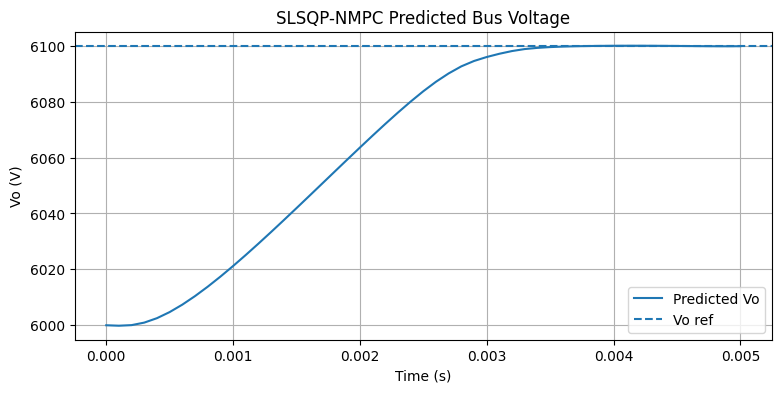

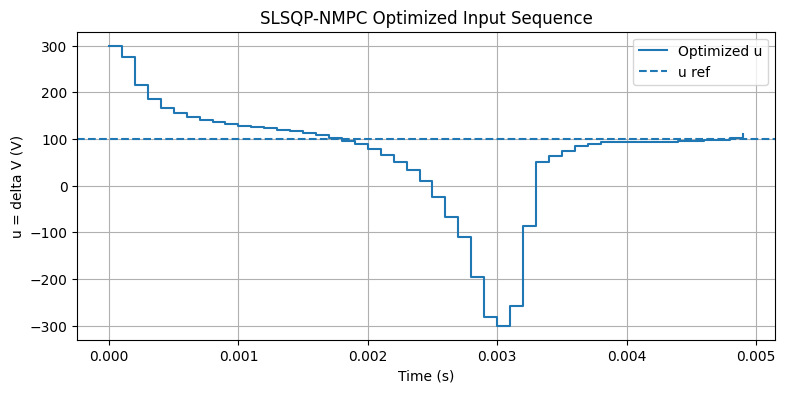

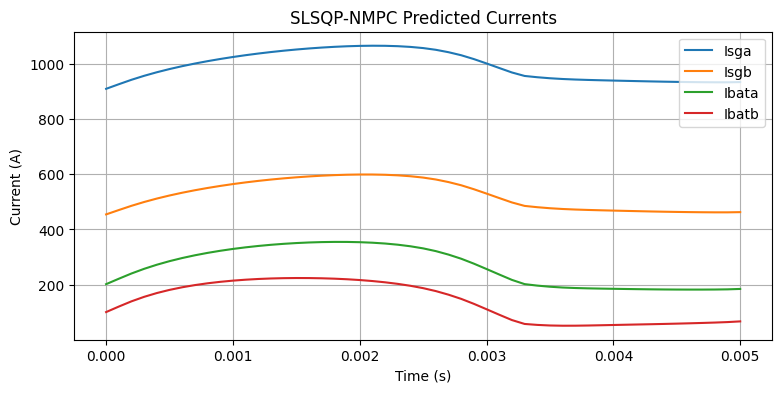

In [51]:
# ============================================================
# Plot SLSQP-NMPC prediction
# ============================================================

t_x = np.arange(Np + 1) * dt_phys_np
t_u = np.arange(Np) * dt_phys_np

plt.figure(figsize=(9, 4))
plt.plot(t_x, X_pred_opt_np[:, 0], label="Predicted Vo")
plt.axhline(x_ref_abs_np[0], linestyle="--", label="Vo ref")
plt.xlabel("Time (s)")
plt.ylabel("Vo (V)")
plt.title("SLSQP-NMPC Predicted Bus Voltage")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.step(t_u, U_opt_abs_np[:, 0], where="post", label="Optimized u")
plt.axhline(u_ref_abs_np[0], linestyle="--", label="u ref")
plt.xlabel("Time (s)")
plt.ylabel("u = delta V (V)")
plt.title("SLSQP-NMPC Optimized Input Sequence")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(t_x, X_pred_opt_np[:, 1], label="Isga")
plt.plot(t_x, X_pred_opt_np[:, 2], label="Isgb")
plt.plot(t_x, X_pred_opt_np[:, 3], label="Ibata")
plt.plot(t_x, X_pred_opt_np[:, 4], label="Ibatb")
plt.xlabel("Time (s)")
plt.ylabel("Current (A)")
plt.title("SLSQP-NMPC Predicted Currents")
plt.legend()
plt.grid(True)
plt.show()

In [52]:
print(solve_info["success"])
print(solve_info["terminal_value"])
print(solve_info["alpha"])
print(solve_info["terminal_margin"])
print(solve_info["u0"])

True
154.0525008919868
7182.166141496297
7028.113640604311
299.99999999999983


In [53]:
print("U_opt min:", np.min(U_opt_abs_np))
print("U_opt max:", np.max(U_opt_abs_np))
print("U_opt first 10:")
print(U_opt_abs_np[:10].reshape(-1))

num_at_upper = np.sum(np.isclose(U_opt_abs_np, 300.0, atol=1e-6))
num_at_lower = np.sum(np.isclose(U_opt_abs_np, -300.0, atol=1e-6))

print("Number at upper bound:", num_at_upper, "/", U_opt_abs_np.shape[0])
print("Number at lower bound:", num_at_lower, "/", U_opt_abs_np.shape[0])

U_opt min: -300.0
U_opt max: 299.99999999999983
U_opt first 10:
[300.         275.5454784  215.67445551 185.21354256 167.09779778
 155.34594448 147.12180988 141.09070849 136.32544317 132.44981188]
Number at upper bound: 1 / 50
Number at lower bound: 1 / 50


In [54]:
# ============================================================
# True MVDC dynamics in NumPy
# ============================================================

def true_mvdc_dynamics_np(x_abs, u_abs, d_abs, params):
    """
    True nonlinear MVDC dynamics.

    x_abs shape: [5]
    u_abs shape: [1] or scalar
    d_abs shape: [1] or scalar
    """

    Vo = x_abs[0]
    Isga = x_abs[1]
    Isgb = x_abs[2]
    Ibata = x_abs[3]
    Ibatb = x_abs[4]

    u = float(np.asarray(u_abs).reshape(-1)[0])
    PCPL = float(np.asarray(d_abs).reshape(-1)[0])

    Ceq = params["Ceq"]
    Lsg = params["Lsg"]
    Lbat = params["Lbat"]

    Rsga = params["Rsga"]
    Rsgb = params["Rsgb"]
    Rbata = params["Rbata"]
    Rbatb = params["Rbatb"]

    Vref = params["Vref"]

    Vo_safe = max(Vo, 1.0)

    dVo = (
        Isga
        + Isgb
        + Ibata
        + Ibatb
        - PCPL / Vo_safe
    ) / Ceq

    dIsga = (Vref - Rsga * Isga - Vo + u) / Lsg
    dIsgb = (Vref - Rsgb * Isgb - Vo + u) / Lsg
    dIbata = (Vref - Rbata * Ibata - Vo + u) / Lbat
    dIbatb = (Vref - Rbatb * Ibatb - Vo + u) / Lbat

    dxdt = np.array(
        [dVo, dIsga, dIsgb, dIbata, dIbatb],
        dtype=np.float64
    )

    return dxdt


def rk4_step_true_mvdc_np(x_abs, u_abs, d_abs, dt, params):
    k1 = true_mvdc_dynamics_np(x_abs, u_abs, d_abs, params)
    k2 = true_mvdc_dynamics_np(x_abs + 0.5 * dt * k1, u_abs, d_abs, params)
    k3 = true_mvdc_dynamics_np(x_abs + 0.5 * dt * k2, u_abs, d_abs, params)
    k4 = true_mvdc_dynamics_np(x_abs + dt * k3, u_abs, d_abs, params)

    x_next = x_abs + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    return x_next

In [55]:
# ============================================================
# Closed-loop NMPC simulation
# ============================================================

def simulate_closed_loop_nmpc_slsqp_np(
    x0_abs,
    num_cl_steps,
    Np,
    d_ref_abs,
    z_ref,
    x_ref_abs,
    u_ref_abs,
    weights,
    params,
    x_op,
    u_op,
    d_op,
    x_scale,
    u_scale,
    d_scale,
    dt_phys,
    dt_model,
    Q,
    R,
    P_f,
    alpha,
    u_min=-300.0,
    u_max=300.0,
    move_weight=0.01,
    curvature_weight=0.01,
    maxiter=80,
    ftol=1e-6
):
    """
    Closed-loop NMPC:
        1. solve SLSQP
        2. apply u0 to true nonlinear plant
        3. shift horizon
    """

    x_current = np.asarray(x0_abs, dtype=np.float64).reshape(-1)

    X_hist = [x_current.copy()]
    U_hist = []
    terminal_hist = []
    success_hist = []
    cost_hist = []

    # Initial guess
    U_guess = np.tile(u_ref_abs.reshape(1, 1), (Np, 1))

    u_prev = u_op.copy()

    for k in range(num_cl_steps):
        D_horizon = np.tile(d_ref_abs.reshape(1, 1), (Np, 1))

        U_opt, Z_pred, X_pred, solve_info, result = solve_nmpc_slsqp_np(
            x0_abs=x_current,
            D_abs=D_horizon,
            U_init_abs=U_guess,
            z_ref=z_ref,
            u_ref_abs=u_ref_abs,
            weights=weights,
            x_op=x_op,
            u_op=u_op,
            d_op=d_op,
            x_scale=x_scale,
            u_scale=u_scale,
            d_scale=d_scale,
            dt_model=dt_model,
            Q=Q,
            R=R,
            P_f=P_f,
            alpha=alpha,
            u_min=u_min,
            u_max=u_max,
            u_prev_abs=u_prev,
            move_weight=move_weight,
            curvature_weight=curvature_weight,
            maxiter=maxiter,
            ftol=ftol,
            disp=False
        )

        u0 = U_opt[0, 0]

        # Apply u0 to true plant
        x_next = rk4_step_true_mvdc_np(
            x_abs=x_current,
            u_abs=np.array([u0]),
            d_abs=d_ref_abs,
            dt=dt_phys,
            params=params
        )

        X_hist.append(x_next.copy())
        U_hist.append(u0)

        terminal_hist.append(solve_info["terminal_value"])
        success_hist.append(solve_info["success"])
        cost_hist.append(solve_info["final_cost"])

        # Warm start: shift optimal sequence
        U_guess = np.vstack([
            U_opt[1:, :],
            U_opt[-1:, :]
        ])

        u_prev = np.array([u0], dtype=np.float64)
        x_current = x_next

        if k % 10 == 0:
            print(
                f"k={k:03d} | "
                f"success={solve_info['success']} | "
                f"Vo={x_current[0]:.2f} | "
                f"u0={u0:.2f} | "
                f"terminal={solve_info['terminal_value']:.2f} | "
                f"margin={solve_info['terminal_margin']:.2f}"
            )

    X_hist = np.array(X_hist)
    U_hist = np.array(U_hist).reshape(-1, 1)
    terminal_hist = np.array(terminal_hist)
    success_hist = np.array(success_hist)
    cost_hist = np.array(cost_hist)

    return X_hist, U_hist, terminal_hist, success_hist, cost_hist

In [56]:
# ============================================================
# Run closed-loop NMPC
# ============================================================

num_cl_steps = 100
Np = 20

x0_cl_np = x_op_np.copy()

X_cl_np, U_cl_np, terminal_cl_np, success_cl_np, cost_cl_np = simulate_closed_loop_nmpc_slsqp_np(
    x0_abs=x0_cl_np,
    num_cl_steps=num_cl_steps,
    Np=Np,
    d_ref_abs=d_ref_abs_np,
    z_ref=z_ref_np,
    x_ref_abs=x_ref_abs_np,
    u_ref_abs=u_ref_abs_np,
    weights=node_weights_np,
    params=params,
    x_op=x_op_np,
    u_op=u_op_np,
    d_op=d_op_np,
    x_scale=x_scale_np,
    u_scale=u_scale_np,
    d_scale=d_scale_np,
    dt_phys=dt_phys_np,
    dt_model=dt_model_np,
    Q=Q_np,
    R=R_np,
    P_f=P_f_np,
    alpha=alpha_slsqp_np,
    u_min=-300.0,
    u_max=300.0,
    move_weight=0.01,
    curvature_weight=0.01,
    maxiter=80,
    ftol=1e-6
)

print("Closed-loop success rate:", np.mean(success_cl_np))

k=000 | success=True | Vo=6000.67 | u0=300.00 | terminal=2484.50 | margin=4697.66
k=010 | success=False | Vo=6043.76 | u0=109.19 | terminal=273.17 | margin=6908.99
k=020 | success=False | Vo=6096.86 | u0=-248.16 | terminal=143.88 | margin=7038.28
k=030 | success=True | Vo=6100.22 | u0=90.28 | terminal=99.66 | margin=7082.50
k=040 | success=True | Vo=6100.14 | u0=95.49 | terminal=70.25 | margin=7111.91
k=050 | success=True | Vo=6100.07 | u0=96.39 | terminal=50.50 | margin=7131.67
k=060 | success=True | Vo=6100.04 | u0=97.03 | terminal=36.91 | margin=7145.25
k=070 | success=True | Vo=6100.02 | u0=98.15 | terminal=27.39 | margin=7154.77
k=080 | success=True | Vo=6100.01 | u0=98.54 | terminal=20.61 | margin=7161.56
k=090 | success=True | Vo=6100.00 | u0=98.34 | terminal=15.71 | margin=7166.46
Closed-loop success rate: 0.81


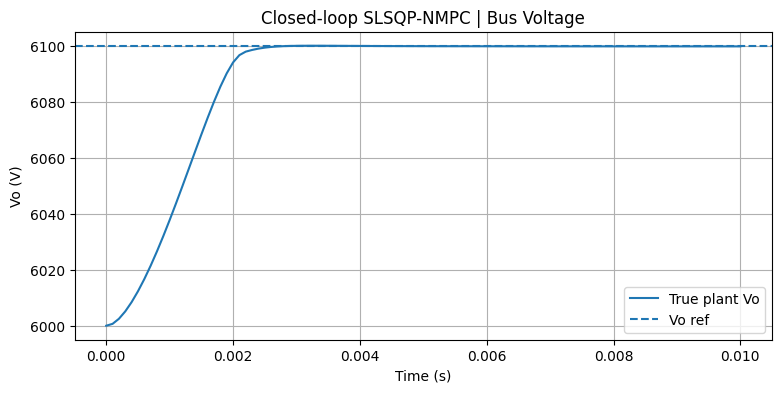

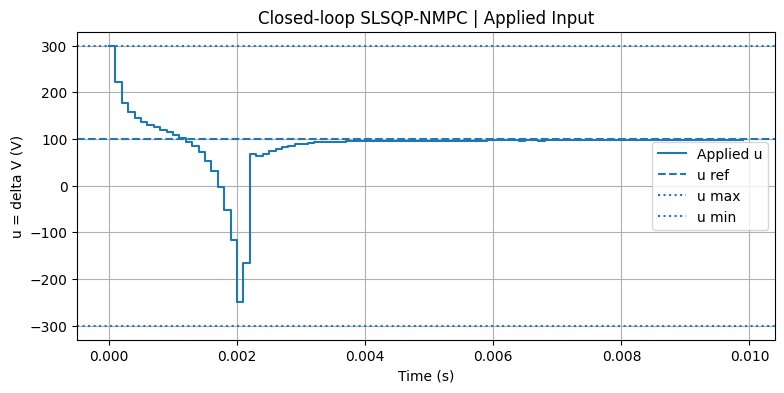

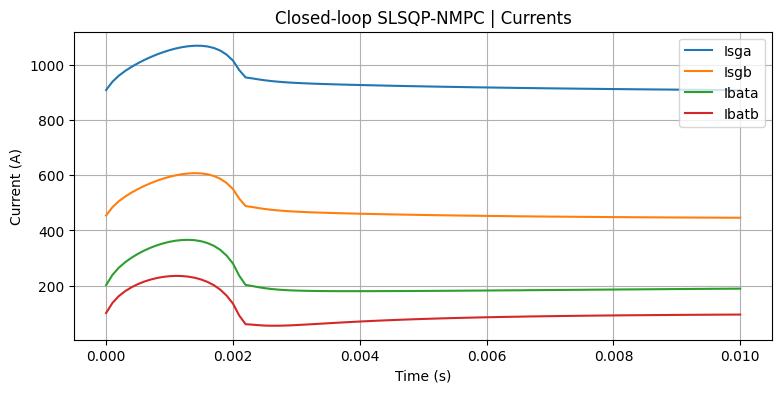

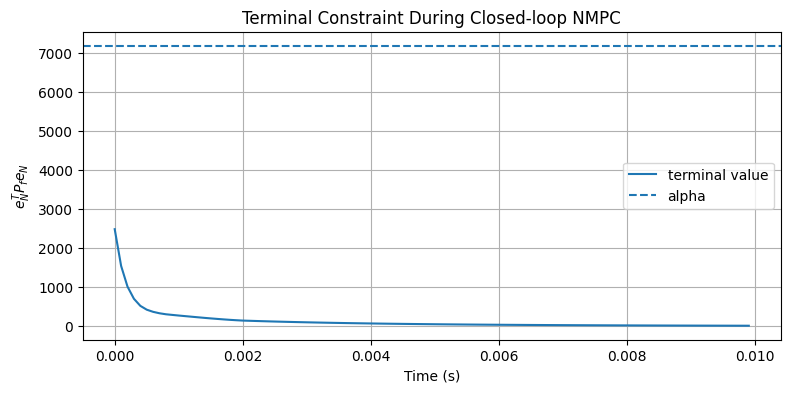

In [57]:
# ============================================================
#  Plot closed-loop results
# ============================================================

t_x = np.arange(num_cl_steps + 1) * dt_phys_np
t_u = np.arange(num_cl_steps) * dt_phys_np

plt.figure(figsize=(9, 4))
plt.plot(t_x, X_cl_np[:, 0], label="True plant Vo")
plt.axhline(x_ref_abs_np[0], linestyle="--", label="Vo ref")
plt.xlabel("Time (s)")
plt.ylabel("Vo (V)")
plt.title("Closed-loop SLSQP-NMPC | Bus Voltage")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.step(t_u, U_cl_np[:, 0], where="post", label="Applied u")
plt.axhline(u_ref_abs_np[0], linestyle="--", label="u ref")
plt.axhline(300.0, linestyle=":", label="u max")
plt.axhline(-300.0, linestyle=":", label="u min")
plt.xlabel("Time (s)")
plt.ylabel("u = delta V (V)")
plt.title("Closed-loop SLSQP-NMPC | Applied Input")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(t_x, X_cl_np[:, 1], label="Isga")
plt.plot(t_x, X_cl_np[:, 2], label="Isgb")
plt.plot(t_x, X_cl_np[:, 3], label="Ibata")
plt.plot(t_x, X_cl_np[:, 4], label="Ibatb")
plt.xlabel("Time (s)")
plt.ylabel("Current (A)")
plt.title("Closed-loop SLSQP-NMPC | Currents")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(t_u, terminal_cl_np, label="terminal value")
plt.axhline(alpha_slsqp_np, linestyle="--", label="alpha")
plt.xlabel("Time (s)")
plt.ylabel(r"$e_N^T P_f e_N$")
plt.title("Terminal Constraint During Closed-loop NMPC")
plt.legend()
plt.grid(True)
plt.show()

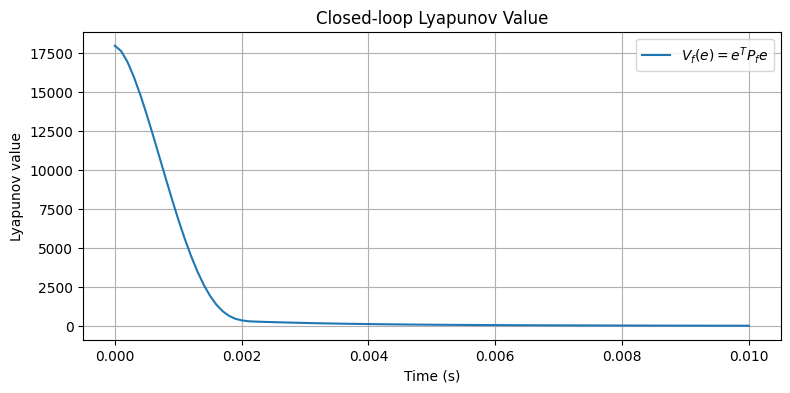

Initial V: 17979.766026750433
Final V: 19.12448078084073
V decreased overall: True


In [58]:
# ============================================================
# Check Lyapunov value along closed-loop trajectory
# ============================================================

def compute_closed_loop_lyapunov_np(X_hist, x_ref_abs, x_op, x_scale, P_f):
    Z_hist = (X_hist - x_op.reshape(1, -1)) / x_scale.reshape(1, -1)
    z_ref = (x_ref_abs - x_op) / x_scale

    E_hist = Z_hist - z_ref.reshape(1, -1)

    V_hist = np.array([
        e @ P_f @ e
        for e in E_hist
    ])

    return V_hist


V_cl_np = compute_closed_loop_lyapunov_np(
    X_hist=X_cl_np,
    x_ref_abs=x_ref_abs_np,
    x_op=x_op_np,
    x_scale=x_scale_np,
    P_f=P_f_np
)

plt.figure(figsize=(9, 4))
plt.plot(np.arange(len(V_cl_np)) * dt_phys_np, V_cl_np, label=r"$V_f(e)=e^TP_fe$")
plt.xlabel("Time (s)")
plt.ylabel("Lyapunov value")
plt.title("Closed-loop Lyapunov Value")
plt.legend()
plt.grid(True)
plt.show()

print("Initial V:", V_cl_np[0])
print("Final V:", V_cl_np[-1])
print("V decreased overall:", V_cl_np[-1] < V_cl_np[0])

In [59]:
print("Closed-loop success rate:", np.mean(success_cl_np))
print("Max terminal value:", np.max(terminal_cl_np))
print("Alpha:", alpha_slsqp_np)
print("Terminal always feasible:", np.all(terminal_cl_np <= alpha_slsqp_np))

Closed-loop success rate: 0.81
Max terminal value: 2484.5048544941556
Alpha: 7182.166141496297
Terminal always feasible: True


In [60]:
failed_idx = np.where(success_cl_np == False)[0]

print("Number of failed solves:", len(failed_idx))
print("Failed indices:", failed_idx[:30])

Number of failed solves: 19
Failed indices: [ 3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]


In [61]:
feasible_cl_np = terminal_cl_np <= alpha_slsqp_np

print("SLSQP success rate:", np.mean(success_cl_np))
print("Feasible rate:", np.mean(feasible_cl_np))
print("Terminal always feasible:", np.all(feasible_cl_np))

SLSQP success rate: 0.81
Feasible rate: 1.0
Terminal always feasible: True
